# Utility data EDA and cleaning

Link to dataset: https://catalog.data.gov/dataset/u-s-electric-utility-companies-and-rates-look-up-by-zip-code-2024

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

We have two files, one for investor-owned utilities and one for non investory-owned utilities.

In [6]:
utility_iou = pd.read_csv("../data/raw/iou_zipcodes_2024.csv", dtype={"zip": str})
utility_non_iou = pd.read_csv("../data/raw/non_iou_zipcodes_2024.csv", dtype={"zip": str})

In [7]:
utility_iou.head()

,zip,eiaid,utility_name,state,service_type,ownership,comm_rate,ind_rate,res_rate
0,85321,176,Ajo Improvement Co,AZ,Bundled,Investor Owned,0.114389,0.000000,0.125649
1,36560,195,Alabama Power Co,AL,Bundled,Investor Owned,0.148399,0.079544,0.167720
2,36513,195,Alabama Power Co,AL,Bundled,Investor Owned,0.148399,0.079544,0.167720
3,36280,195,Alabama Power Co,AL,Bundled,Investor Owned,0.148399,0.079544,0.167720
4,35473,195,Alabama Power Co,AL,Bundled,Investor Owned,0.148399,0.079544,0.167720


In [8]:
utility_non_iou.head()

,zip,eiaid,utility_name,state,service_type,ownership,comm_rate,ind_rate,res_rate
0,39730,55,City of Aberdeen - (MS),MS,Bundled,Municipal,0.120785,0.056459,0.122988
1,38858,55,City of Aberdeen - (MS),MS,Bundled,Municipal,0.120785,0.056459,0.122988
2,21864,84,A & N Electric Coop,MD,Bundled,Cooperative,0.135450,0.000000,0.136927
3,21824,84,A & N Electric Coop,MD,Bundled,Cooperative,0.135450,0.000000,0.136927
4,21866,84,A & N Electric Coop,MD,Bundled,Cooperative,0.135450,0.000000,0.136927


In [9]:
utility_iou.shape, utility_non_iou.shape

((49004, 9), (28009, 9))

In [10]:
# drop eiaid, not needed
utility_iou.drop(columns=['eiaid', 'ind_rate', 'comm_rate'], inplace=True)
utility_non_iou.drop(columns=['eiaid', 'ind_rate', 'comm_rate'], inplace=True)

Examine service types:

In [11]:
utility_iou['service_type'].unique()

array(['Bundled', 'Delivery'], dtype=object)

In [12]:
utility_non_iou['service_type'].unique()

array(['Bundled', 'Energy', 'Delivery'], dtype=object)

For investor-owned utilities, service type can be 'Bundled' or 'Delivery'. For non investor-owned, service type could also be 'Energy'.

In [13]:
utility_iou['service_type'].value_counts()

service_type
Bundled     33286
Delivery    15718
Name: count, dtype: int64

In [14]:
utility_non_iou['service_type'].value_counts()

service_type
Bundled     27517
Delivery      483
Energy          9
Name: count, dtype: int64

In [15]:
# there are just 9 rows with service_type of 'Energy'
utility_non_iou[utility_non_iou['service_type'] == 'Energy']

,zip,utility_name,state,service_type,ownership,res_rate
4543,92503,City of Corona - (CA),CA,Energy,Municipal,0.0
4544,92860,City of Corona - (CA),CA,Energy,Municipal,0.0
4545,92883,City of Corona - (CA),CA,Energy,Municipal,0.0
4546,92882,City of Corona - (CA),CA,Energy,Municipal,0.0
4547,92879,City of Corona - (CA),CA,Energy,Municipal,0.0
4548,92881,City of Corona - (CA),CA,Energy,Municipal,0.0
4549,92880,City of Corona - (CA),CA,Energy,Municipal,0.0
4550,92878,City of Corona - (CA),CA,Energy,Municipal,0.0
4551,92877,City of Corona - (CA),CA,Energy,Municipal,0.0


'Delivery' and 'Energy' service types have a lower rate because it only includes part of the cost. 'Delivery' only covers cost of delivery, 'Energy' only covers cost of generation. Bundled includes both generation and delivery costs. Need to remove rows with service type of delivery since these will artificially bring down the rate.

In [18]:
# analyze rates by service type
utility_iou.groupby('service_type')['res_rate'].mean().sort_values()

service_type
Delivery    0.103941
Bundled     0.180906
Name: res_rate, dtype: float64

In [19]:
utility_non_iou.groupby('service_type')['res_rate'].mean().sort_values(ascending=False)

service_type
Bundled     0.133902
Delivery    0.118909
Energy      0.000000
Name: res_rate, dtype: float64

Before we remove any rows, we want to make sure that we aren't losing a lot of zip codes

In [20]:
all_zips = set(utility_iou['zip'])
utility_iou_bundled = utility_iou[utility_iou['service_type'] == 'Bundled']
bundled_zips = set(utility_iou_bundled['zip'])

lost_zips = all_zips - bundled_zips
print(f"ZIP codes that will be lost by removing non-'Bundled' rows: {len(lost_zips):,}")

lost_rows = len(utility_iou) - len(utility_iou_bundled)
print(f"Rows that will be lost by removing non-'Bundled' rows: {lost_rows}")

ZIP codes that will be lost by removing non-'Bundled' rows: 0
Rows that will be lost by removing non-'Bundled' rows: 15718


In [21]:
rows_per_zip = utility_iou.groupby("zip")["utility_name"].count().mean().item()
rows_per_zip_bundled = utility_iou_bundled.groupby("zip")["utility_name"].count().mean().item()

print(f"Rows per zip code before removing non-'Bundled' rows: {rows_per_zip}")
print(f"Rows per zip code after removing non-'Bundled' rows: {rows_per_zip_bundled}")

Rows per zip code before removing non-'Bundled' rows: 1.6091153871412622
Rows per zip code after removing non-'Bundled' rows: 1.0929927103171997


Same check for non-investor owned:

In [22]:
all_zips = set(utility_non_iou['zip'])
utility_non_iou_bundled = utility_non_iou[utility_non_iou['service_type'] == 'Bundled']
bundled_zips = set(utility_non_iou_bundled['zip'])

lost_zips = all_zips - bundled_zips
print(f"ZIP codes that will be lost by removing 'non-'Bundled' rows: {len(lost_zips):,}")


lost_rows = len(utility_non_iou) - len(utility_non_iou_bundled)
print(f"Rows that will be lost by removing 'non-'Bundled' rows: {lost_rows}")

ZIP codes that will be lost by removing 'non-'Bundled' rows: 0
Rows that will be lost by removing 'non-'Bundled' rows: 492


In [23]:
rows_per_zip = utility_non_iou.groupby("zip")["utility_name"].count().mean().item()
rows_per_zip_bundled = utility_non_iou_bundled.groupby("zip")["utility_name"].count().mean().item()

print(f"Rows per zip code before removing non-'Bundled' rows: {rows_per_zip}")
print(f"Rows per zip code after removing non-'Bundled' rows: {rows_per_zip_bundled}")

Rows per zip code before removing non-'Bundled' rows: 1.456526261050442
Rows per zip code after removing non-'Bundled' rows: 1.4309412376495059


It turns out that every zip code has at least one row where service_type = 'Bundled'. We can safely remove any rows with a service_type of 'Delivery' or 'Energy' and still have utility rate data for every zip code.

We will now combine the data for investor-owned and non investor-owned utilities into one DataFrame:

In [24]:
# combine the data frames
utility_combined = pd.concat([utility_iou, utility_non_iou], ignore_index=True)
utility = utility_combined[utility_combined['service_type'] == 'Bundled'].reset_index(drop=True)

In [25]:
print(f"States covered: {utility['state'].nunique()} (counting Washington, D.C.)")
print(f"Total rows: {len(utility)}")
print(f"Rows removed: {len(utility_combined) - len(utility)}")

States covered: 51 (counting Washington, D.C.)
Total rows: 60803
Rows removed: 16210


In [26]:
# double check that no zip codes were lost
utility_combined['zip'].nunique(), utility['zip'].nunique()

(38585, 38585)

In [27]:
utility

,zip,utility_name,state,service_type,ownership,res_rate
0,85321,Ajo Improvement Co,AZ,Bundled,Investor Owned,0.125649
1,36560,Alabama Power Co,AL,Bundled,Investor Owned,0.167720
2,36513,Alabama Power Co,AL,Bundled,Investor Owned,0.167720
3,36280,Alabama Power Co,AL,Bundled,Investor Owned,0.167720
4,35473,Alabama Power Co,AL,Bundled,Investor Owned,0.167720
...,...,...,...,...,...,...
60798,76540,Heart of Texas Electric Coop,TX,Bundled,Cooperative,0.126238
60799,76703,Heart of Texas Electric Coop,TX,Bundled,Cooperative,0.126238
60800,76702,Heart of Texas Electric Coop,TX,Bundled,Cooperative,0.126238
60801,76597,Heart of Texas Electric Coop,TX,Bundled,Cooperative,0.126238


No nulls values in the combine data.

In [28]:
utility.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60803 entries, 0 to 60802
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   zip           60803 non-null  object 
 1   utility_name  60803 non-null  object 
 2   state         60803 non-null  object 
 3   service_type  60803 non-null  object 
 4   ownership     60803 non-null  object 
 5   res_rate      60803 non-null  float64
dtypes: float64(1), object(5)
memory usage: 2.8+ MB


Check for outliers: all three rates have minimum values of 0, which are certainly not real values.

In [29]:
utility.describe()

,res_rate
count,60803.000000
mean,0.159634
std,0.068204
min,0.000000
25%,0.127473
50%,0.146709
75%,0.170166
max,0.699487


We will now observe all rows where the rate is 0.

In [30]:
zeros = utility[utility["res_rate"] == 0]
print(f"Rows with res_rate = 0: {len(zeros):,}")
print(f"Unique ZIPs affected: {zeros['zip'].nunique():,}")
print(f"\nUtilities with zero residential rate:")
print(zeros.groupby(["utility_name", "state"]).size().sort_values(ascending=False).head(20))

Rows with res_rate = 0: 1,804
Unique ZIPs affected: 1,804

Utilities with zero residential rate:
utility_name                           state
Tennessee Valley Authority             TN       788
                                       AL       331
                                       KY       317
                                       MS       250
                                       NC       105
City of Escondido - (CA)               CA        10
Southwestern Electric Coop Inc - (NM)  OK         2
Y-W Electric Assn Inc                  NE         1
dtype: int64


There are just 4 utility companies who have rates of 0 for some zips:

In [31]:
zeros['utility_name'].unique()

array(['City of Escondido - (CA)',
       'Southwestern Electric Coop Inc - (NM)',
       'Tennessee Valley Authority', 'Y-W Electric Assn Inc'],
      dtype=object)

We will now analyze what will happen to the data if we remove rows with a rate of 0:

In [33]:
# get number of rows and zips before removing any rows
n_rows_before = len(utility)
n_zips_before = utility["zip"].nunique()

# get unique zips before
zips_before = set(utility["zip"])

# drops rows where res_rate is zero
utility_clean = utility[utility["res_rate"] > 0].copy()

# get num rows, zips after dropping
n_rows_after = len(utility_clean)
n_rows_lost = n_rows_before - n_rows_after

# get unique zips after
zips_after = set(utility_clean["zip"])
n_zips_after = utility_clean["zip"].nunique()


# find the zips that will be lost from dropping
zips_lost = zips_before - zips_after

# display results
print(f"Rows before:    {n_rows_before}")
print(f"Rows after:     {n_rows_after}")
print(f"Rows removed:   {n_rows_lost}")
print(f"Percent of rows removed: {(n_rows_lost/n_rows_before)*100:.2f}%")

print()

print(f"ZIPs before:    {n_zips_before}")
print(f"ZIPs after:     {n_zips_after}")
print(f"ZIPs lost:      {len(zips_lost)}")
print(f"Percent of zips removed: {(len(zips_lost)/n_zips_before)*100:.2f}%")

lost_states = (
    utility[utility["zip"].isin(zips_lost)]
    .groupby("state").size().sort_values(ascending=False)
)
print(f"\nLost ZIPs by state:")
print(lost_states)

Rows before:    60803
Rows after:     58999
Rows removed:   1804
Percent of rows removed: 2.97%

ZIPs before:    38585
ZIPs after:     38564
ZIPs lost:      21
Percent of zips removed: 0.05%

Lost ZIPs by state:
state
TN    14
CA     3
AL     2
KY     1
MS     1
dtype: int64


We are losing a small portion of the data by dropping - we still have 58,999 rows and 38564 zip codes to analyze

In [34]:
# drop rows with 0 res_rate:
utility_clean = utility[utility["res_rate"] > 0].copy()

In [35]:
print("Overview:")
print(f"Total rows: {len(utility_clean):,}")
print(f"Unique ZIPs: {utility_clean['zip'].nunique():,}")
print(f"Unique utilities: {utility_clean['utility_name'].nunique():,}")
print(f"\nResidential rate distribution:")
print(utility_clean["res_rate"].describe())

Overview:
Total rows: 58,999
Unique ZIPs: 38,564
Unique utilities: 1,192

Residential rate distribution:
count    58999.000000
mean         0.164515
std          0.063174
min          0.031497
25%          0.129427
50%          0.148876
75%          0.170990
max          0.699487
Name: res_rate, dtype: float64


Observe rows with rates that are much higher than the mean

In [36]:
high = utility_clean[utility_clean["res_rate"] > 0.30].sort_values("res_rate", ascending=False)
print(f"Rows with res_rate > $0.30/kWh: {len(high):,}")
print(high[["zip", "utility_name", "state", "res_rate"]].head(25))

Rows with res_rate > $0.30/kWh: 3,319
         zip                   utility_name state  res_rate
33507  99770  Alaska Village Elec Coop, Inc    AK  0.699487
33492  99554  Alaska Village Elec Coop, Inc    AK  0.699487
33494  99730  Alaska Village Elec Coop, Inc    AK  0.699487
33519  99657  Alaska Village Elec Coop, Inc    AK  0.699487
33518  99651  Alaska Village Elec Coop, Inc    AK  0.699487
33517  99658  Alaska Village Elec Coop, Inc    AK  0.699487
33516  99578  Alaska Village Elec Coop, Inc    AK  0.699487
33515  99655  Alaska Village Elec Coop, Inc    AK  0.699487
33514  99602  Alaska Village Elec Coop, Inc    AK  0.699487
33513  99630  Alaska Village Elec Coop, Inc    AK  0.699487
33512  99589  Alaska Village Elec Coop, Inc    AK  0.699487
33511  99665  Alaska Village Elec Coop, Inc    AK  0.699487
33510  99749  Alaska Village Elec Coop, Inc    AK  0.699487
33509  99742  Alaska Village Elec Coop, Inc    AK  0.699487
33508  99758  Alaska Village Elec Coop, Inc    AK  0.699487
33

In [37]:
high['state'].unique()

array(['AK', 'HI', 'CA', 'MA', 'RI', 'NY', 'NM', 'CT'], dtype=object)

These states experience high electricity rates primarily due to geographic isolation (Alaska and Hawaii) and infrastructure constraints that make fuel transport and grid maintenance exceptionally expensive. Many of these regions, particularly California and the Northeast, also face higher costs from aggressive clean energy policies and "grid hardening" to prevent climate-related disasters like wildfires. 

The combination of older transmission systems and a heavy reliance on imported natural gas or oil keeps their prices well above the national average.

In [38]:
low = utility_clean[utility_clean["res_rate"] < 0.05].sort_values("res_rate", ascending=True)
print(f"Rows with res_rate < $0.05/kWh: {len(low):,}")
print(low[["zip", "utility_name", "state", "res_rate"]].head(len(low)))

Rows with res_rate < $0.05/kWh: 51
         zip                utility_name state  res_rate
38960  98926  PUD No 1 of Douglas County    WA  0.031497
38938  99123  PUD No 1 of Douglas County    WA  0.031497
38939  98802  PUD No 1 of Douglas County    WA  0.031497
38940  98816  PUD No 1 of Douglas County    WA  0.031497
38941  98823  PUD No 1 of Douglas County    WA  0.031497
38942  98801  PUD No 1 of Douglas County    WA  0.031497
38943  99116  PUD No 1 of Douglas County    WA  0.031497
38944  98813  PUD No 1 of Douglas County    WA  0.031497
38945  98812  PUD No 1 of Douglas County    WA  0.031497
38946  98848  PUD No 1 of Douglas County    WA  0.031497
38948  99133  PUD No 1 of Douglas County    WA  0.031497
38947  98850  PUD No 1 of Douglas County    WA  0.031497
38950  98828  PUD No 1 of Douglas County    WA  0.031497
38951  98851  PUD No 1 of Douglas County    WA  0.031497
38952  98830  PUD No 1 of Douglas County    WA  0.031497
38953  98845  PUD No 1 of Douglas County    WA  0.031

These areas in Washington state have multiple major hydroelectric dams. This is one of the cheapest forms of energy to generate, so it makes sense that it has the lowest rates in the country.

View average rate by state:

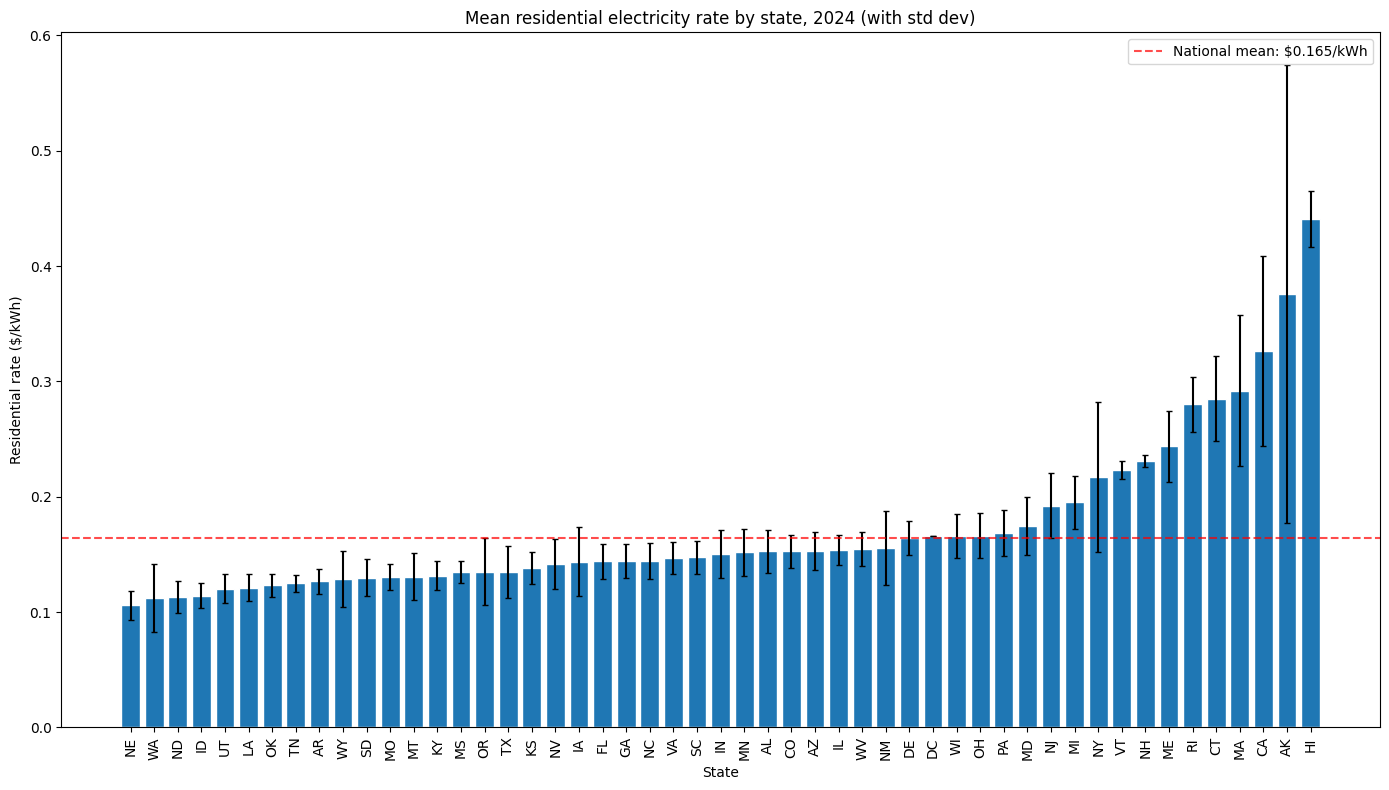

In [39]:
# get mean rate per state and sort
state_means = (
    utility_clean
    .groupby("state")["res_rate"]
    .mean()
    .sort_values()
)

# Also get standard deviation for error bars (optional but informative)
state_stds = utility_clean.groupby("state")["res_rate"].std()

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(state_means.index, state_means.values,
       yerr=state_stds[state_means.index].values,
       capsize=2, edgecolor="white")

# Reference line for national mean
national_mean = utility_clean["res_rate"].mean()
ax.axhline(national_mean, color="red", linestyle="--", alpha=0.7,
           label=f"National mean: ${national_mean:.3f}/kWh")

ax.set_xlabel("State")
ax.set_ylabel("Residential rate ($/kWh)")
ax.set_title("Mean residential electricity rate by state, 2024 (with std dev)")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Save the cleaned data

In [40]:
utility_clean.to_csv("../data/processed/utility_bundled.csv", index=False)